# Table of Contents

* __[1. Import Data](#import)__
  * [1.1 Import the needed libraries and documents into Jupyter Notebook](#lib)
  * [1.2. Check for duplicates](#duplicates)
* __[2. Explore Data](#explore_data)__
  * [2.1 Basic Exploration](#basic_exploration)
* __[3. Modifying data (Data preparation)](#modify_data)__
  * [3.1. Gender](#gender)
  * [3.2. Age](#age)
  * [3.3. S5_MaterialQuality](#S5_variable)
  * [3.4. Newsletter_Subscription](#newsletter)
  * [3.5. Missing Values](#missing_values)
  * [3.6. K-Fold Cross-Validation](#kfold)
    * [3.6.1. Feature Selection](#feature_selection)
* __[4. Model & Assess (Modelling and Assessment)](#model_assess)__
  * [4.1. Model Selection](#model_selection)
    * [4.1.1. Compare different algorithms and select the most promising ones](#comparing_algorithms)
  * [4.2. Model Optimization](#model_optimization)

<a name='import'>
    
<font color = '#BED62F'>
    
# **1. Import Data** </font>
</a>

<a name='lib'></a>

<font color = '#BED62F'>

## **1.1. Import the needed libraries and documents into Jupyter Notebook**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency
from datetime import datetime


from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE # wrapper method
from sklearn.linear_model import LogisticRegression #(This is one possible model to apply inside RFE)
from sklearn.linear_model import LassoCV # embedded method
from sklearn.impute import KNNImputer


from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import  f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from pprint import pprint


from sklearn.ensemble import RandomForestClassifier,  GradientBoostingClassifier, VotingClassifier, AdaBoostClassifier
import xgboost as xgb
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC


from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin
from sklearn.pipeline import Pipeline


In [4]:
# Import the train dataset and define the index as the Cust_ID
data = pd.read_csv(r'data/train.csv')
data.set_index("Cust_ID", inplace=True)

In [5]:
data

,Buy_product,Name,Newsletter_Subscription,Year_Birth,Membership,Preferred_Game_Genre,FidelityPoints,S1_GameplayExperience,S2_GameMechanics,S3_GameBalance,...,S5_MaterialQuality,S6_ValueForPrice,S7_Artwork_Design,S8_ThemeIntegration,S9_PlayerIteration,S10_LevelAdjust,S11_RuleClarity,S12_StrategicThinking,S13_ReplayValue,S14_Recommendation
Cust_ID,,,,,,,,,,,,,,,,,,,,,
1,0,Ms. Nicole Clarke,yes,1974.0,Premium,Strategy,4907,3,4,1,...,4,3,4,3,3,3,3,4,3,4
2,1,Mr. Jesse Scott,yes,1965.0,Premium,Strategy,6724,1,1,1,...,5,3,4,5,5,5,5,1,5,2
3,0,Mr. Christopher Carter,yes,1973.0,Premium,Strategy,4365,3,3,3,...,1,4,4,3,3,2,3,2,3,1
4,1,Ms. Jennifer Morgan,yes,1993.0,Non-Premium,Party,3849,1,1,1,...,4,4,5,4,4,4,4,4,4,3
5,1,Mr. Michael White,yes,1989.0,Premium,Strategy,5376,2,2,3,...,5,5,5,5,5,3,4,1,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15585,0,Ms. Wendy Roberts,no,1988.0,Premium,Party,4968,2,0,2,...,3,2,4,3,4,5,1,3,4,3
15586,0,Ms. Sonya Smith,no,2000.0,Premium,Party,4970,3,3,3,...,5,3,5,5,3,1,3,4,4,5
15587,1,Mr. Maxwell Wright,yes,1964.0,Premium,Strategy,4046,1,1,1,...,3,4,5,4,4,4,4,5,4,4


<a name='explore_data'></a>

<font color = '#C04000'>
    
# **2. Explore Data (Data access, exploration and understanding)** </font>

<a name='basic_exploration'></a>

<font color = '#C04000'>

## **2.1. Basic Exploration**

In [6]:
# Making a copy of the data to maintain the original
data_processed = data.copy()

In [7]:
data_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15589 entries, 1 to 15589
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Buy_product              15589 non-null  int64  
 1   Name                     15589 non-null  object 
 2   Newsletter_Subscription  15589 non-null  object 
 3   Year_Birth               15394 non-null  float64
 4   Membership               15589 non-null  object 
 5   Preferred_Game_Genre     15589 non-null  object 
 6   FidelityPoints           15589 non-null  int64  
 7   S1_GameplayExperience    15589 non-null  int64  
 8   S2_GameMechanics         15589 non-null  int64  
 9   S3_GameBalance           15589 non-null  int64  
 10  S4_GameLength            15589 non-null  int64  
 11  S5_MaterialQuality       15589 non-null  int64  
 12  S6_ValueForPrice         15589 non-null  int64  
 13  S7_Artwork_Design        15589 non-null  int64  
 14  S8_ThemeIntegration      15

We can check there are missing values in `'Year_Birth'`.

In [8]:
# Checking summary statistics for numerical variables
data_processed.describe().T

,count,mean,std,min,25%,50%,75%,max
Buy_product,15589.0,0.543781,0.498096,0.0,0.0,1.0,1.0,1.0
Year_Birth,15394.0,1981.706444,15.179042,1936.0,1970.0,1981.0,1994.0,2014.0
FidelityPoints,15589.0,5022.593816,1027.962379,409.0,4445.0,5088.0,5649.0,6950.0
S1_GameplayExperience,15589.0,2.841619,1.388624,0.0,2.0,3.0,4.0,5.0
S2_GameMechanics,15589.0,2.997242,1.518994,0.0,2.0,3.0,4.0,5.0
S3_GameBalance,15589.0,2.844570,1.436948,0.0,2.0,3.0,4.0,5.0
S4_GameLength,15589.0,2.986016,1.299438,1.0,2.0,3.0,4.0,5.0
S5_MaterialQuality,15589.0,3.245109,1.327026,0.0,2.0,3.0,4.0,6.0
S6_ValueForPrice,15589.0,3.374816,1.352417,0.0,2.0,4.0,4.0,5.0
S7_Artwork_Design,15589.0,3.506383,1.319565,1.0,3.0,4.0,5.0,5.0


We can check that:
* `'S5_MaterialQuality'` has max of __6.0__, which is an incorrect grade, we need to replace them further.
* `Year_Birth` has some nulls.
* `Buy_product ha`s a skewed distribution. Lets see it further.

In [9]:
# Checking all categorical variables
data_processed.describe(include='O')

,Name,Newsletter_Subscription,Membership,Preferred_Game_Genre
count,15589,15589,15589,15589
unique,14227,3,2,3
top,Mr. Michael Smith,yes,Premium,Strategy
freq,9,12548,10756,7442


We can check that there are:
* 3 different unique results for `'Newsletter_Subscription'`;
* 2 different unique values for `Membership`;
* 3 different unique values for `Preferred_Game_Genre`. <br><br>
We should check them.

In [10]:
# Checking 'Newsletter_Subscription' values
data_processed["Newsletter_Subscription"].unique()

array(['yes', 'no', 'y'], dtype=object)

* We have 2 possible values to yes: y and yes. __We will modify them further sticking with one of them.__

In [11]:
# Checking 'Membership' values
data_processed["Membership"].unique()

array(['Premium', 'Non-Premium'], dtype=object)

In [12]:
# Checking 'Preferred_Game_Genre' values
data_processed["Preferred_Game_Genre"].unique()

array(['Strategy', 'Party', 'Thematic'], dtype=object)

<a name='modify_data'></a>

<font color = '#C04000'>
    
# **3. Modifying data (Data preparation)** </font>

<a name='gender'></a>

<font color = '#C04000'>
    
## **3.1. Gender** </font>

In [13]:
# Creating a new column "Gender" from "Name" column
data_processed['Gender'] = data_processed['Name'].apply(lambda x: 'F' if x.split(' ')[0]=='Ms.' else 'M')

In [14]:
data_processed[['Name','Gender']].head(3)

,Name,Gender
Cust_ID,,
1,Ms. Nicole Clarke,F
2,Mr. Jesse Scott,M
3,Mr. Christopher Carter,M


In [15]:
# Dropping 'Name' column
data_processed.drop('Name', axis=1, inplace=True)

<a name='age'></a>

<font color = '#C04000'>
    
## **3.2. Age** </font>

In [16]:
# Creating a new column "Age" from "Year_Birth" column
data_processed['Age'] = datetime.now().year - data_processed['Year_Birth']

In [17]:
data_processed[['Year_Birth','Age']].head(3)

,Year_Birth,Age
Cust_ID,,
1,1974.0,50.0
2,1965.0,59.0
3,1973.0,51.0


In [18]:
# Dropping 'Year_Birth' column
data_processed.drop('Year_Birth', axis=1, inplace=True)

In [19]:
# data_processed['Age'] = data_processed['Age'].astype(int)

<a name='S5_variable'></a>

<font color = '#C04000'>
    
## **3.3. S5_MaterialQuality** </font>

In [20]:
# Filling 'S5_MaterialQuality' 6.0 values with 5.0
data['S5_MaterialQuality'] = data['S5_MaterialQuality'].replace(6.0, 5.0)

<a name='newsletter'></a>

<font color = '#C04000'>
    
## **3.4. Newsletter_Subscription** </font>

In [21]:
data_processed["Newsletter_Subscription"]=data["Newsletter_Subscription"].replace({"y":"yes"})

In [22]:
data_processed["Newsletter_Subscription"].unique()

array(['yes', 'no'], dtype=object)

<a name='missing_values'></a>

<font color = '#C04000'>
    
## **3.5. Missing Values** </font>

Applying KNN Imputer to fill the missing values in 'Age' column

In [23]:
data_dummies_knn = pd.get_dummies(data_processed)
data_dummies_knn.drop(['Buy_product','Newsletter_Subscription_no', 'Membership_Non-Premium', 'Preferred_Game_Genre_Party', 'Gender_F'], axis=1, inplace=True)

In [24]:
data_dummies_knn.head(3)

,FidelityPoints,S1_GameplayExperience,S2_GameMechanics,S3_GameBalance,S4_GameLength,S5_MaterialQuality,S6_ValueForPrice,S7_Artwork_Design,S8_ThemeIntegration,S9_PlayerIteration,...,S11_RuleClarity,S12_StrategicThinking,S13_ReplayValue,S14_Recommendation,Age,Newsletter_Subscription_yes,Membership_Premium,Preferred_Game_Genre_Strategy,Preferred_Game_Genre_Thematic,Gender_M
Cust_ID,,,,,,,,,,,,,,,,,,,,,
1,4907,3,4,1,4,4,3,4,3,3,...,3,4,3,4,50.0,True,True,True,False,False
2,6724,1,1,1,1,5,3,4,5,5,...,5,1,5,2,59.0,True,True,True,False,True
3,4365,3,3,3,3,1,4,4,3,3,...,3,2,3,1,51.0,True,True,True,False,True


In [25]:
data_dummies_knn[data_dummies_knn['Age'].isna()]

,FidelityPoints,S1_GameplayExperience,S2_GameMechanics,S3_GameBalance,S4_GameLength,S5_MaterialQuality,S6_ValueForPrice,S7_Artwork_Design,S8_ThemeIntegration,S9_PlayerIteration,...,S11_RuleClarity,S12_StrategicThinking,S13_ReplayValue,S14_Recommendation,Age,Newsletter_Subscription_yes,Membership_Premium,Preferred_Game_Genre_Strategy,Preferred_Game_Genre_Thematic,Gender_M
Cust_ID,,,,,,,,,,,,,,,,,,,,,
28,4760,0,5,0,3,5,0,3,5,4,...,5,4,4,5,NaN,True,False,False,False,False
127,5151,2,2,2,2,2,2,2,2,3,...,3,2,4,2,NaN,True,True,False,False,False
148,5370,4,4,4,2,2,4,2,2,5,...,4,4,4,2,NaN,False,True,True,False,False
169,3669,1,1,1,1,5,5,5,5,4,...,5,4,4,5,NaN,True,True,True,False,False
171,4593,1,1,1,1,2,4,5,4,4,...,5,2,4,4,NaN,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15280,5769,0,4,0,2,3,4,1,2,2,...,2,5,2,2,NaN,True,False,False,False,False
15303,4196,4,5,5,3,1,5,1,1,5,...,4,3,4,1,NaN,True,False,False,False,True
15389,6448,3,3,3,3,4,5,4,5,5,...,5,3,5,5,NaN,True,True,True,False,False


In [26]:
# Initialize KNNImputer
imputer = KNNImputer(n_neighbors=5)

# Fit the imputer on the subset of columns used to calculate neighbors
imputer.fit(data_dummies_knn)

# If you only want to impute column 'Age' and keep the rest unchanged:
data_transformed = imputer.transform(data_dummies_knn)

# Identify the indices of missing values in the 'Age' column
missing_age_indices = np.isnan(data_dummies_knn['Age'])

# Update the original 'Age' column with imputed values (rounded to the nearest integer)
data_processed.loc[missing_age_indices, 'Age'] = np.round(data_transformed[missing_age_indices, 15]).astype(int)

In [27]:
data_processed['Age'] = data_processed['Age'].astype(int)

In [28]:
data_processed['Age'].count()

15589

In [29]:
data_processed['Age'].isnull().sum()

0

In [30]:
# data_processed.columns

In [31]:
data_processed

,Buy_product,Newsletter_Subscription,Membership,Preferred_Game_Genre,FidelityPoints,S1_GameplayExperience,S2_GameMechanics,S3_GameBalance,S4_GameLength,S5_MaterialQuality,...,S7_Artwork_Design,S8_ThemeIntegration,S9_PlayerIteration,S10_LevelAdjust,S11_RuleClarity,S12_StrategicThinking,S13_ReplayValue,S14_Recommendation,Gender,Age
Cust_ID,,,,,,,,,,,,,,,,,,,,,
1,0,yes,Premium,Strategy,4907,3,4,1,4,4,...,4,3,3,3,3,4,3,4,F,50
2,1,yes,Premium,Strategy,6724,1,1,1,1,5,...,4,5,5,5,5,1,5,2,M,59
3,0,yes,Premium,Strategy,4365,3,3,3,3,1,...,4,3,3,2,3,2,3,1,M,51
4,1,yes,Non-Premium,Party,3849,1,1,1,1,4,...,5,4,4,4,4,4,4,3,F,31
5,1,yes,Premium,Strategy,5376,2,2,3,2,5,...,5,5,5,3,4,1,3,5,M,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15585,0,no,Premium,Party,4968,2,0,2,2,3,...,4,3,4,5,1,3,4,3,F,36
15586,0,no,Premium,Party,4970,3,3,3,3,5,...,5,5,3,1,3,4,4,5,F,24
15587,1,yes,Premium,Strategy,4046,1,1,1,1,3,...,5,4,4,4,4,5,4,4,M,60


<a name='kfold'></a>

<font color = '#C04000'>
    
## **3.6. K-Fold Cross-Validation** </font>

Create a new instance of StratifiedKFold named as skf, with the following hyperparameters: <br>
n_splits = 10 (Usually, 10 splits are used) <br>
random_state = 99 <br>
shuffle = True

In [32]:
skf=StratifiedKFold(n_splits = 10, random_state = 99, shuffle = True) # We shuffle the data to have everything mixed to avoid biasing results

To apply any of the model assessment techniques previously mentioned, we need to define at first what are our __independent variables (X) and the target (y)__

In [33]:
X = data_processed.drop('Buy_product', axis=1)
y = data_processed['Buy_product'].copy()

<a name='feature_selection'></a>

<font color = '#C04000'>

### **3.6.1. Feature Selection**

In this step we are going to apply Feature Selection, namely:

* Variance (Filter Method)
* Spearman Correlation (Filter Method)
* Recursive Feature Elimination (RFE) (Wrapper Method)
* Lasso Regression (Wrapper Method)
* Decision Trees (Embedded Method)
* Since we know that regressions are really sensible to correlated features, we should remove the correlated features before applying those techniques, namely Lasso Regression and Recursive Feature Elimination if the estimator used is a regression model.

In that way, we are going to apply the feature selection techniques in the following order: <br>
__(1) Variance__ - To understand if there are any constant variables; <br>
__(2) Spearman Correlation__ - To verify if there are any correlated features; <br>
__(3) Decision Trees__ - To just keep one variable from a group of correlated features; <br>
__(4) RFE__ - To iteratively select features by considering subsets of features; <br>
__(5) Lasso__ - To identify and select important features in a dataset; <br>

Furthermore, to apply Feature selection, we need at first to identify the data type of each variable, since different techniques are specific to different data types.

| Predictor | Data Type |
| --- | --- |
| Buy_Product | Binary |
| Name | Categorical |
| Newsletter_Subscription | Categorical |
| Membership | Categorical |
| Preferred_Game_Genre | Categorical |
| FidelityPoints | Continuous |
| S1_GameplayExperience | Ordinal |
| --- | --- |
| S14_Recommendation | Ordinal |

<a name='categorical_features'></a>

<font color = '#C04000'>

#### **3.6.1.1. Categorical Features**

<a name='chi_square'></a>

<font color = '#C04000'>

##### **3.6.1.1.1. Chi-Square (Filter Method) - For categorical data**

Using chi-square to understand which categorical and ordinal variables should we keep

In [34]:
# Creating a function named as apply_chisquare to select features from the categorical variables using chi2_contigencyfrom scipy.stats
def apply_chisquare(X,y,var,alpha=0.05):
    dfObserved = pd.crosstab(y,X)
    chi2, p, dof, expected = stats.chi2_contingency(dfObserved.values)
    dfExpected = pd.DataFrame(expected, columns=dfObserved.columns, index = dfObserved.index)
    if p<alpha:
        result="{0} is IMPORTANT for Prediction".format(var)
    else:
        result="{0} is NOT an important predictor. (Discard {0} from model)".format(var)
    print(result)

In [35]:
categorical_features = [
    'Gender',
    'Newsletter_Subscription',
    'Membership',
    'Preferred_Game_Genre',
    'S1_GameplayExperience',
    'S2_GameMechanics',
    'S3_GameBalance',
    'S4_GameLength',
    'S5_MaterialQuality',
    'S6_ValueForPrice',
    'S7_Artwork_Design',
    'S8_ThemeIntegration',
    'S9_PlayerIteration',
    'S10_LevelAdjust',
    'S11_RuleClarity',
    'S12_StrategicThinking',
    'S13_ReplayValue',
    'S14_Recommendation'
]

In [36]:
# Creating a function named as select_best_cat_features that receives the independent variables (X) and the target (y)
def select_best_cat_features(X,y):
    count = 1

    ############################################## APPLY SKF ######################################################
    for train_index, val_index in skf.split(X,y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index] #train for training and val for validation
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        #################################### SELECT FEATURES WITH CHI-SQUARE #######################################
        print('_________________________________________________________________________________________________\n')
        print('                                     CHI-SQUARE SPLIT ' + str(count) + '                                    ')
        print('_________________________________________________________________________________________________')

        # check which features to use using chi-square
        X_train_cat = X_train[categorical_features].copy()
        for var in X_train_cat:
            apply_chisquare(X_train_cat[var],y_train, var)

        count+=1

In [37]:
# Calling the function select_best_cat_features passing as arguments your independent variables and your target
select_best_cat_features(X,y)

_________________________________________________________________________________________________

                                     CHI-SQUARE SPLIT 1                                    
_________________________________________________________________________________________________
Gender is IMPORTANT for Prediction
Newsletter_Subscription is IMPORTANT for Prediction
Membership is IMPORTANT for Prediction
Preferred_Game_Genre is IMPORTANT for Prediction
S1_GameplayExperience is IMPORTANT for Prediction
S2_GameMechanics is IMPORTANT for Prediction
S3_GameBalance is IMPORTANT for Prediction
S4_GameLength is IMPORTANT for Prediction
S5_MaterialQuality is IMPORTANT for Prediction
S6_ValueForPrice is IMPORTANT for Prediction
S7_Artwork_Design is IMPORTANT for Prediction
S8_ThemeIntegration is IMPORTANT for Prediction
S9_PlayerIteration is IMPORTANT for Prediction
S10_LevelAdjust is IMPORTANT for Prediction
S11_RuleClarity is IMPORTANT for Prediction
S12_StrategicThinking is IMPORTANT 

According to chi-square result, __we should keep all the variables__.

<a name='numerical_features'></a>

<font color = '#C04000'>

#### **3.6.1.2. Numerical Features**

<a name='variance'></a>

<font color = '#C04000'>

##### **3.6.1.2.1. Variance (Filter Method) - For continuous, ordinal and binary data**

Using variance to understand if our numerical data and ordinal data is constant or quasi-constant

In [38]:
# Creating a function named as apply_variance that receives your training data, and outputs the variance for each feature
def apply_variance(X_train, var):
  print(var + ':' + str(X_train.var()))

Similarly to what we have done in the chi-square test, we will now examine the variance of the independent features in the training data, regardless of the specific train subset being used

In [39]:
numerical_columns = X.select_dtypes(include=[np.number]).columns

In [40]:
# Creating a function named as select_features_variance that receives the independent variables (X) and the target (y)
def select_features_variance(X,y):
    count = 1
    for train_index, val_index in skf.split(X,y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        ######################################### SELECT FEATURES #################################################
        print('_________________________________________________________________________________________________\n')
        print('                                     VARIANCE SPLIT ' + str(count) + '                                    ')
        print('_________________________________________________________________________________________________')

        # check which features to use using variance
        for var in numerical_columns:
          apply_variance(X_train[var], var)

        count+=1

In [41]:
select_features_variance(X,y)

_________________________________________________________________________________________________

                                     VARIANCE SPLIT 1                                    
_________________________________________________________________________________________________
FidelityPoints:1051626.428342346
S1_GameplayExperience:1.9314681425357318
S2_GameMechanics:2.299376421522324
S3_GameBalance:2.065816222144778
S4_GameLength:1.6901565116593278
S5_MaterialQuality:1.7680764877271438
S6_ValueForPrice:1.8286893908335806
S7_Artwork_Design:1.7410105896619636
S8_ThemeIntegration:1.719374697163966
S9_PlayerIteration:1.6128964962964025
S10_LevelAdjust:1.6755841364545858
S11_RuleClarity:1.3392410497612084
S12_StrategicThinking:1.6089188686484452
S13_ReplayValue:1.335149723206049
S14_Recommendation:1.6950349309522683
Age:229.92502332633762
_________________________________________________________________________________________________

                                     VARIANCE 

We can check that __we dont have any constant features__, so we should keep them.

<a name='spearman'></a>

<font color = '#C04000'>

##### **3.6.1.2.2. Spearman Correlation (Filter Method) - For continuous and ordinal data**

Using Spearman correlation to determine if we have redundant variables that should be removed due to their high correlation

In [42]:
# Creating a function named as cor_heatmap that receives a correlation matrix
def cor_heatmap(cor):
    plt.figure(figsize=(9,6))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show()

In [43]:
# Creating a function named apply_correlation that takes your training data as input
def apply_correlation(X_train):
    correlation_data = X_train.copy()
    matrix = correlation_data.corr(method = 'spearman', numeric_only = True)
    cor_heatmap(matrix)

Examining the correlation of the independent features in the training data, regardless of the specific train subset being used

In [44]:
#  Creating a function named as redundant_features that receives the independent variables (X) and the target (y)
def redundant_features(X,y):
    count = 1
    for train_index, val_index in skf.split(X,y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        ######################################### SELECT FEATURES #################################################
        print('_________________________________________________________________________________________________\n')
        print('                                     SPLIT ' + str(count) + '                                    ')
        print('_________________________________________________________________________________________________')

        # check which features to use using spearman correlation
        apply_correlation(X_train)

        count+=1

_________________________________________________________________________________________________

                                     SPLIT 1                                    
_________________________________________________________________________________________________


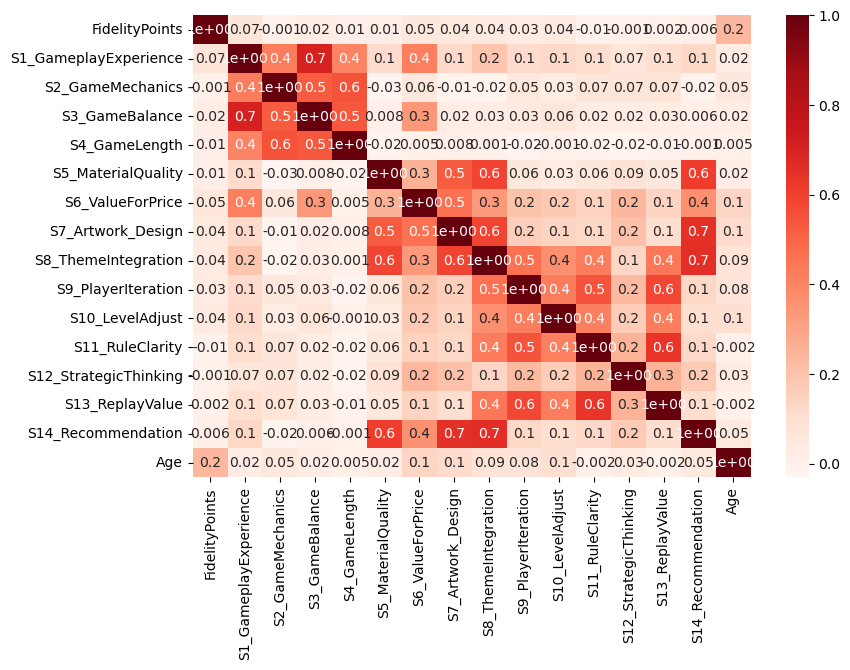

_________________________________________________________________________________________________

                                     SPLIT 2                                    
_________________________________________________________________________________________________


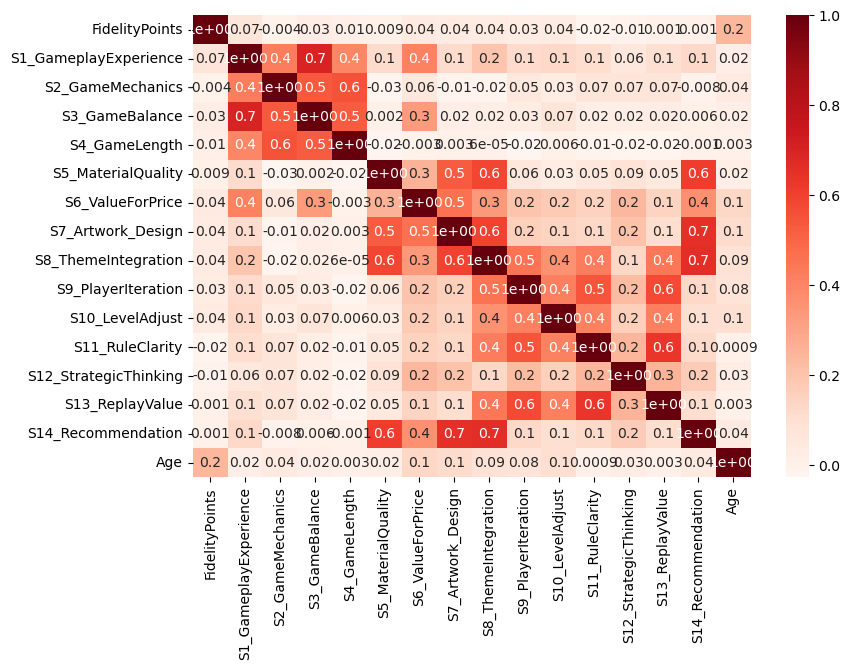

_________________________________________________________________________________________________

                                     SPLIT 3                                    
_________________________________________________________________________________________________


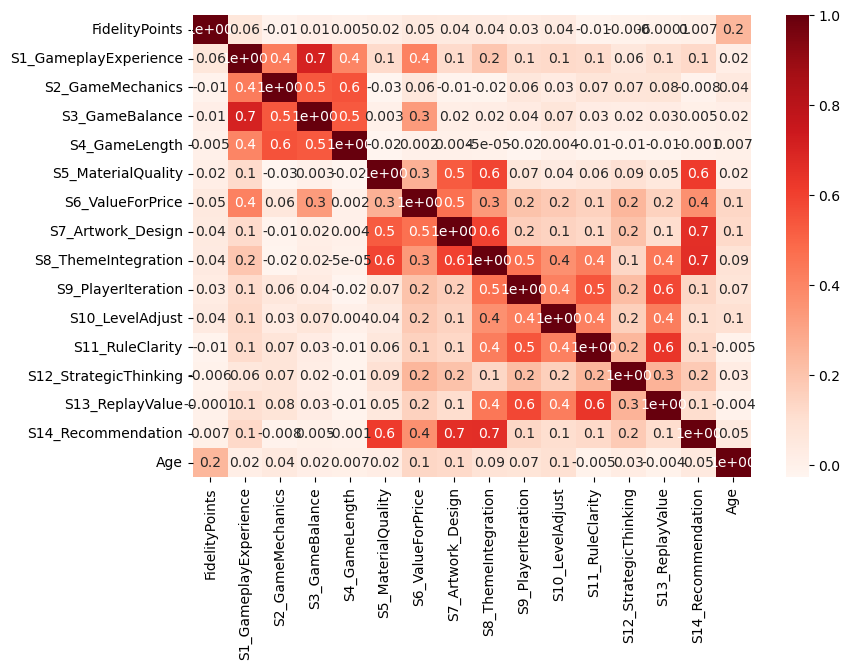

_________________________________________________________________________________________________

                                     SPLIT 4                                    
_________________________________________________________________________________________________


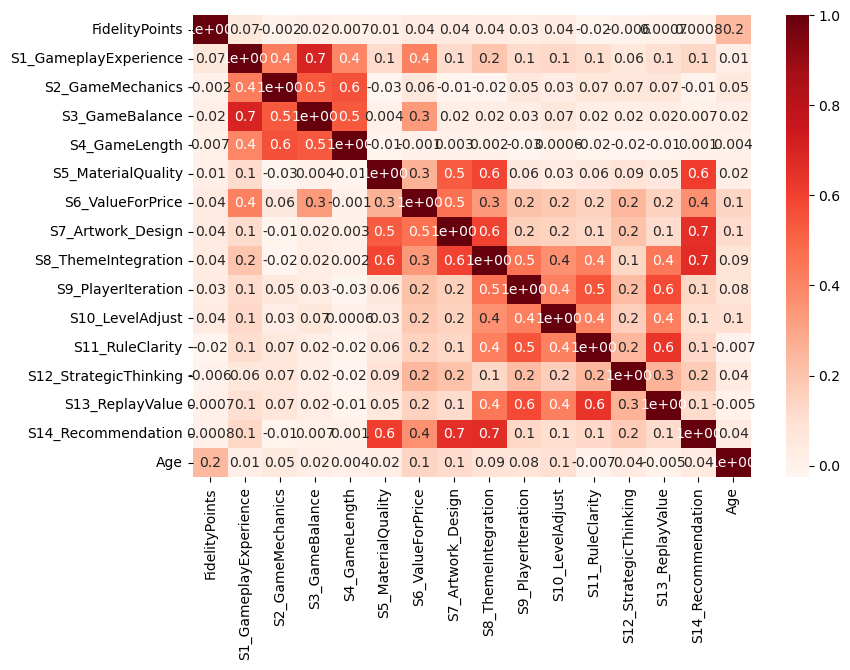

_________________________________________________________________________________________________

                                     SPLIT 5                                    
_________________________________________________________________________________________________


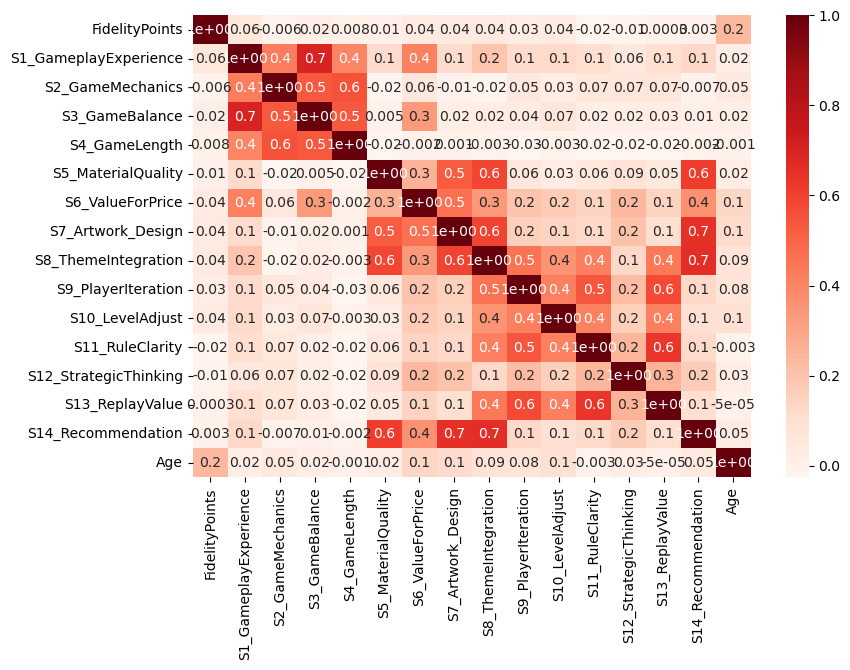

_________________________________________________________________________________________________

                                     SPLIT 6                                    
_________________________________________________________________________________________________


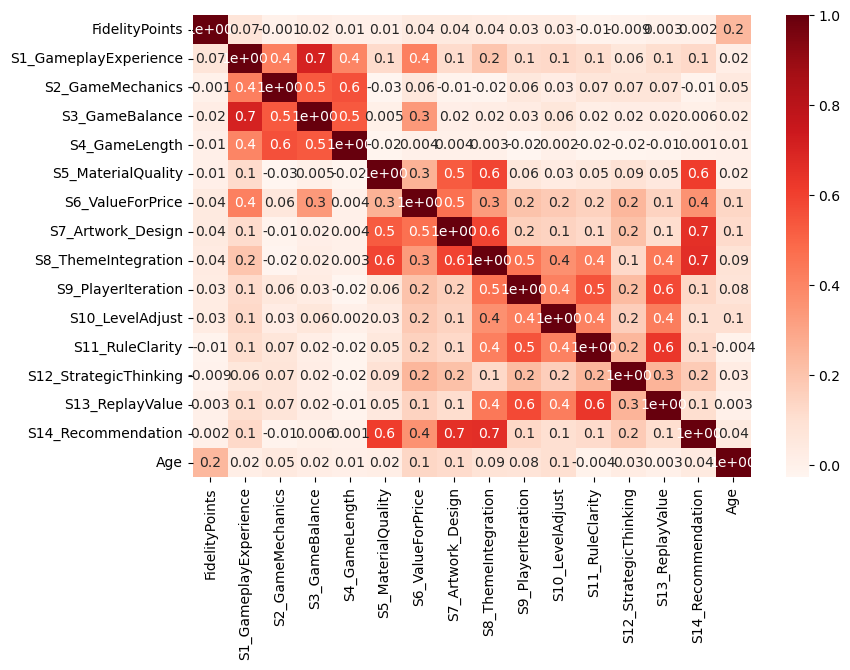

_________________________________________________________________________________________________

                                     SPLIT 7                                    
_________________________________________________________________________________________________


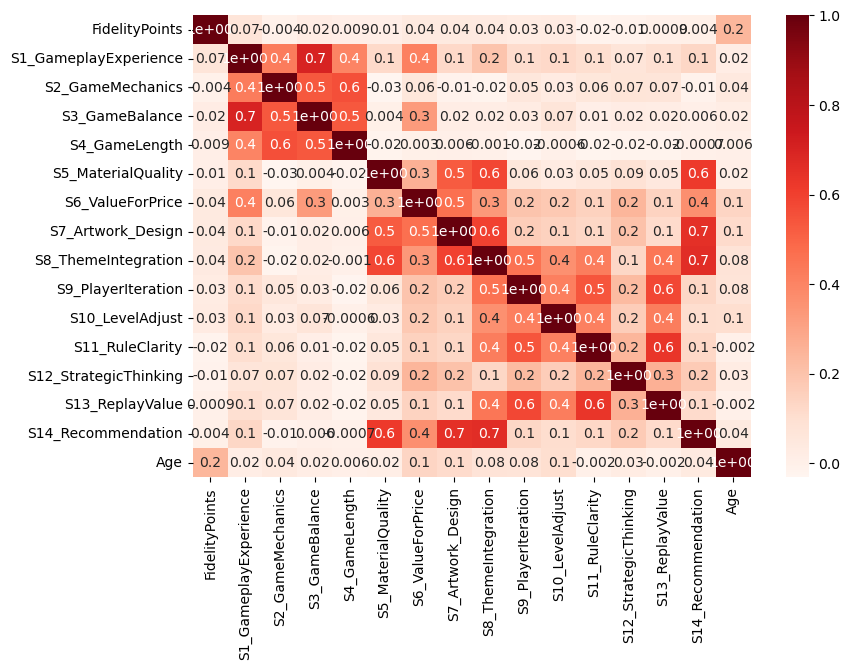

_________________________________________________________________________________________________

                                     SPLIT 8                                    
_________________________________________________________________________________________________


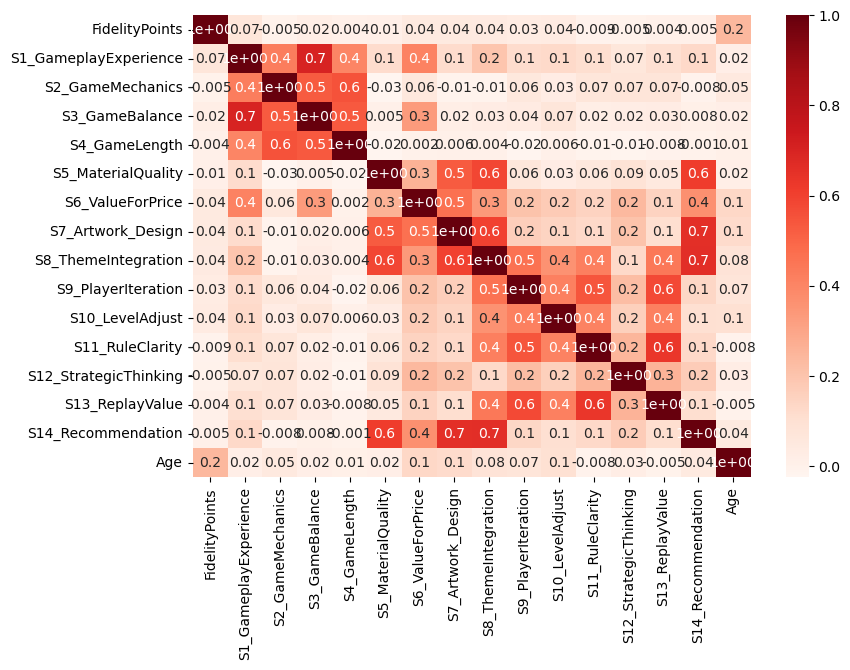

_________________________________________________________________________________________________

                                     SPLIT 9                                    
_________________________________________________________________________________________________


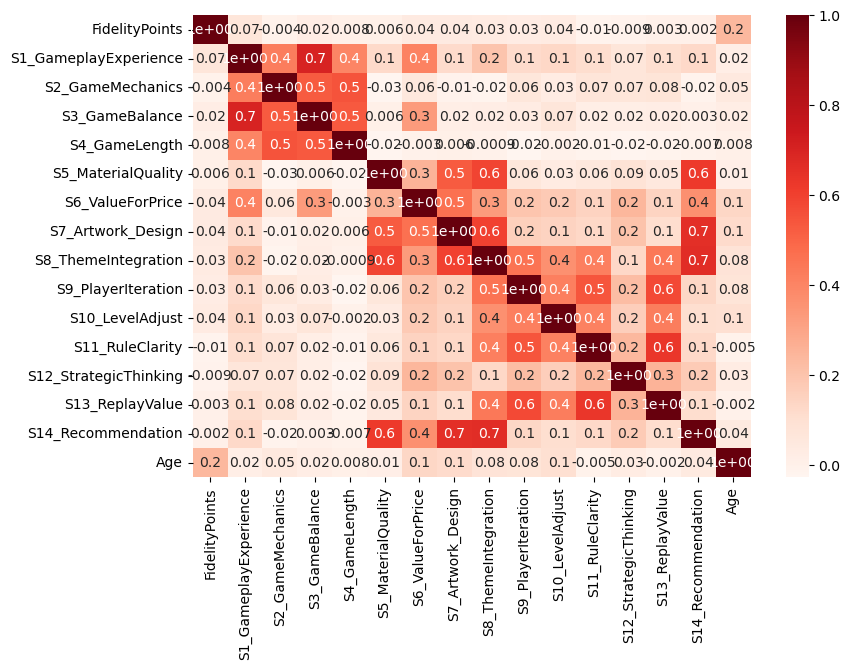

_________________________________________________________________________________________________

                                     SPLIT 10                                    
_________________________________________________________________________________________________


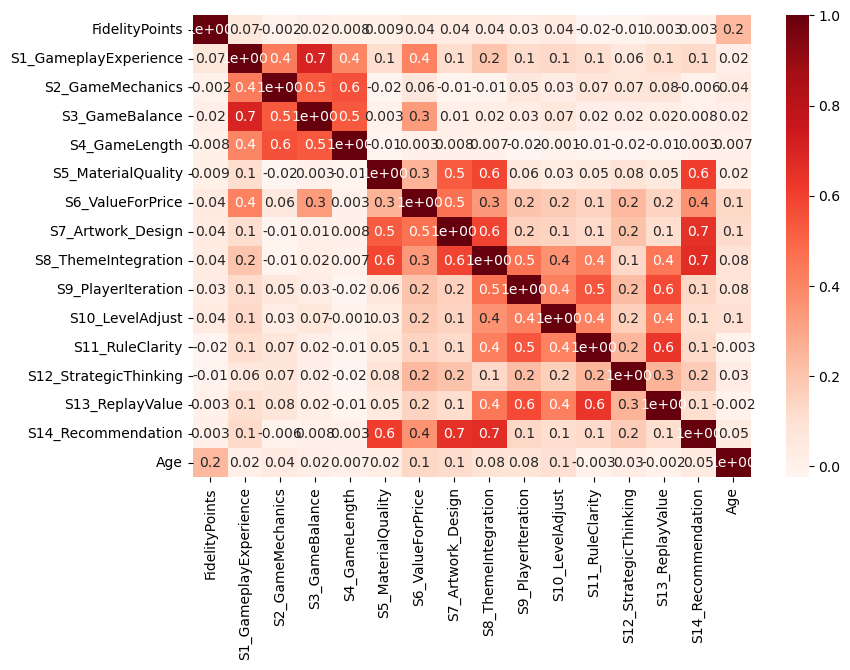

In [45]:
# Calling the function redundant_features passing as arguments your independent variables and your target
redundant_features(X, y)

#### Redundant Variables - Spearman Correlation (Correlation higher than |0.7|)

| Combination | Split 1 | Split 2 | Split 3 | Split 4 | Split 5 | Split 6 | Split 7 | Split 8 | Split 9 | Split 10 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| S1_GameplayExperience Vs S3_GameBalance | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 |
| S7_Artwork_Design Vs S14_Recommendation | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 |
| S8_ThemeIntegration Vs S14_Recommendation | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 | 0.7 |

<a name='decision_trees'></a>

<font color = '#C04000'>

##### **3.6.1.2.3. Decision Trees (Embedded Method) - For continuous, ordinal and binary data**

Examining the feature importance of the independent variables in the training data using a decision tree, regardless of the specific train subset being used

In [46]:
# Creating a function named as plot_importance that receives the feature importances and the name of the model being applied
def plot_importance(variables,name):
    imp_features = variables.sort_values()
    plt.figure(figsize=(4,5))
    imp_features.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.show()

In [47]:
# Creating a function named apply_dt that takes your training data as input (independent variables and target)
def apply_dt(X_train, y_train):
    dt = DecisionTreeClassifier(random_state = 99).fit(X_train, y_train)
    feature_importances = pd.Series(dt.feature_importances_, index = X_train.columns)
    plot_importance(feature_importances, 'DT')

In [48]:
def select_best_features_dt(X, y):
    count = 1
    for train_index, val_index in skf.split(X,y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        ######################################### SELECT FEATURES #################################################
        print('_________________________________________________________________________________________________\n')
        print('                                     SPLIT ' + str(count) + '                                    ')
        print('_________________________________________________________________________________________________')

        # check which features to use using decision Tree
        print(X_train.columns)
        X_train = X_train[numerical_columns]
        apply_dt(X_train, y_train)

        count+=1

_________________________________________________________________________________________________

                                     SPLIT 1                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


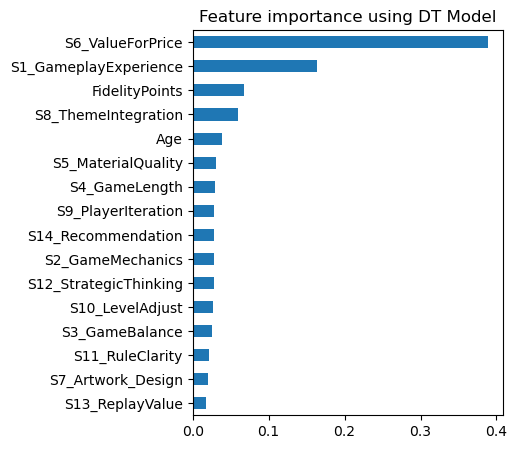

_________________________________________________________________________________________________

                                     SPLIT 2                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


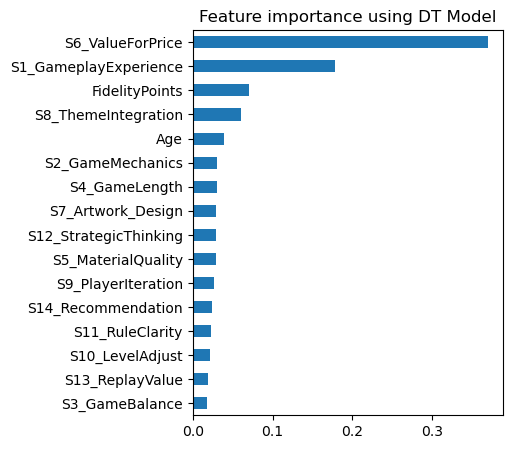

_________________________________________________________________________________________________

                                     SPLIT 3                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


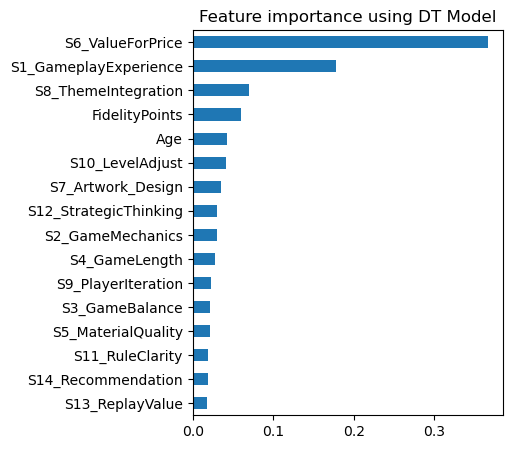

_________________________________________________________________________________________________

                                     SPLIT 4                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


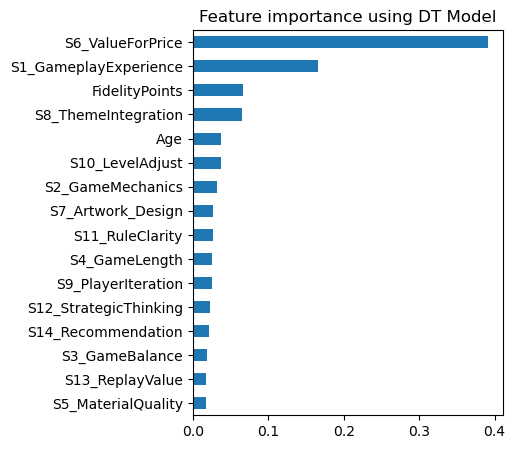

_________________________________________________________________________________________________

                                     SPLIT 5                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


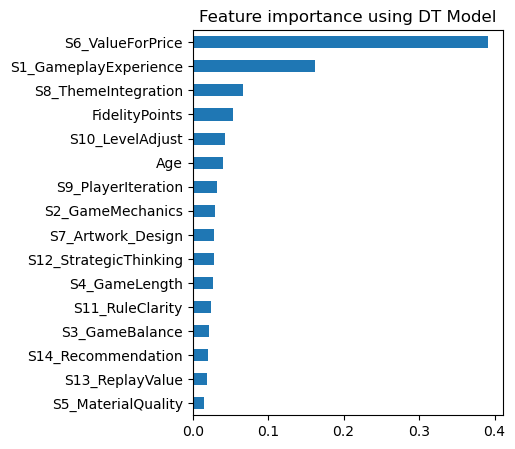

_________________________________________________________________________________________________

                                     SPLIT 6                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


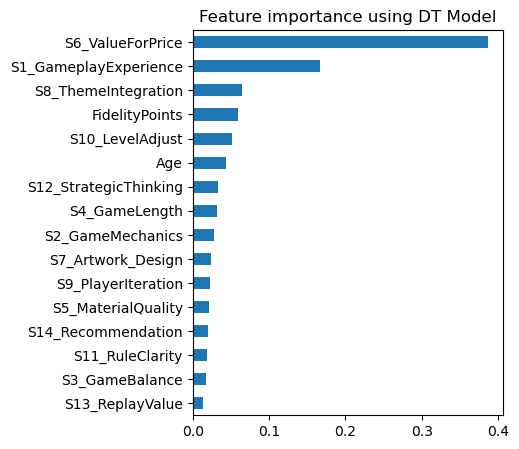

_________________________________________________________________________________________________

                                     SPLIT 7                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


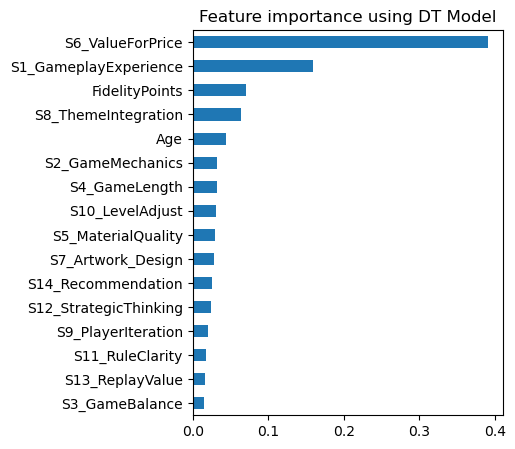

_________________________________________________________________________________________________

                                     SPLIT 8                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


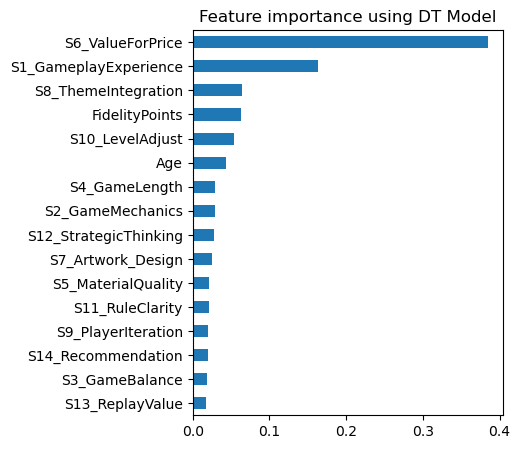

_________________________________________________________________________________________________

                                     SPLIT 9                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


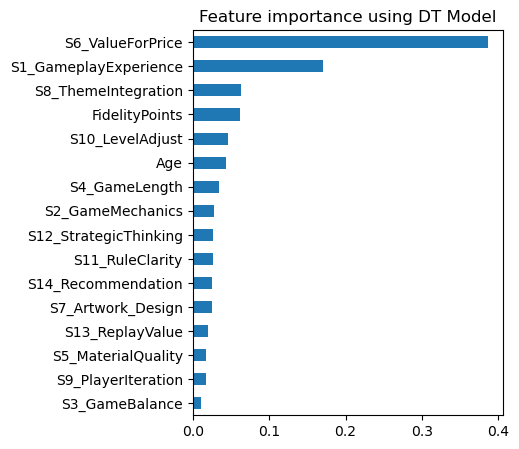

_________________________________________________________________________________________________

                                     SPLIT 10                                    
_________________________________________________________________________________________________
Index(['Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre',
       'FidelityPoints', 'S1_GameplayExperience', 'S2_GameMechanics',
       'S3_GameBalance', 'S4_GameLength', 'S5_MaterialQuality',
       'S6_ValueForPrice', 'S7_Artwork_Design', 'S8_ThemeIntegration',
       'S9_PlayerIteration', 'S10_LevelAdjust', 'S11_RuleClarity',
       'S12_StrategicThinking', 'S13_ReplayValue', 'S14_Recommendation',
       'Gender', 'Age'],
      dtype='object')


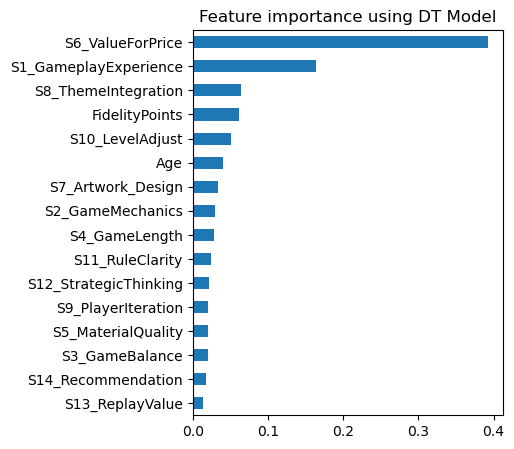

In [49]:
select_best_features_dt(X, y)

- Remove S3_GameBalance, which is highly correlated to S1_GameplayExperience
- Remove S5_MaterialQuality or S13_replayValue??

In [50]:
# X=X.drop(['S3_GameBalance'], axis=1)

In [51]:
# numerical_columns=numerical_columns.difference(['S3_GameBalance'])

To apply Lasso Regression and RFE (using Logistic Regression as an estimator), we should scale our data previously.

<a name='recursive'></a>

<font color = '#C04000'>

##### **3.6.1.2.4. Recursive Feature Elimination (RFE) (Wrapper Method) - For continuous, ordinal and binary data**

Creating a function named apply_rfe that takes your training data as input (independent variables and target). <br>
In this function:
- Create an instance of RFE named as `rfe`, where `estimator = LogisticRegression()` and `n_features_to_select = 5`
- Apply the method `fit_transform()` from `rfe` to your training data.
- Call the attribute from the RFE named `support_` and store those results in a Pandas Series named `selected_features`.
- Print `selected_features`

In [52]:
def apply_rfe(X_train, y_train):
    rfe = RFE(estimator = LogisticRegression(), n_features_to_select = 5)
    rfe.fit_transform(X = X_train, y = y_train)
    selected_features = pd.Series(rfe.support_, index = X_train.columns)
    print(selected_features)

<a name='lasso'></a>

<font color = '#C04000'>

##### **3.6.1.2.5. Lasso - For continuous and ordinal data**

Creating a function named apply_lasso that takes your training data as input (independent variables and target). <br>
In this function:
- Create an instance of LassoCV, and apply the method `fit()`to your training data.
- Call the attribute from the Lasso named `coef_` and store those results in a Pandas Series named `coef`. This will return the coefficients associated with each variable.
- Call the previously defined function `plot_importance` to generate the horizontal bar with the coefficients provided by the Lasso.

In [53]:
def apply_lasso(X_train, y_train):
    lasso = LassoCV().fit(X_train, y_train)
    coef = pd.Series(lasso.coef_, index = X_train.columns)
    plot_importance(coef,'Lasso')

Create a function named as `select_best_features` that receives the independent variables (X) and the target (y). <br>
Inside of this function, follow these steps:
- Apply the previously defined StratifiedKFold as "skf" for cross-validation.
- Drop the `Gender`, `Newsletter_Subscription`, `Membership`, `Preferred_Game_Genre`,  variables, since we are evaluating the numerical data.
- Apply MinMaxScaler to your training data.
- Call the `apply_rfe` function on your data.
- Call the `apply_lasso` function on your data.
- Call the `apply_dt` function on your data.

In [54]:
def select_best_features(X,y):
    count = 1
    for train_index, val_index in skf.split(X,y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        ########################################### SCALE DATA ####################################################
        numerical_data = X_train.drop(['Gender', 'Newsletter_Subscription', 'Membership', 'Preferred_Game_Genre'], axis = 1).copy()
        scaler = MinMaxScaler().fit(numerical_data)
        X_train_scaled = scaler.transform(numerical_data)
        X_train_scaled = pd.DataFrame(X_train_scaled, columns = numerical_data.columns)

        ######################################### SELECT FEATURES #################################################
        print('_________________________________________________________________________________________________\n')
        print('                                     SPLIT ' + str(count) + '                                    ')
        print('_________________________________________________________________________________________________')

        # Check which features to use using RFE
        print('')
        print('----------------- RFE ----------------------')
        apply_rfe(X_train_scaled, y_train)

        # check which features to use using lasso
        print('')
        print('----------------- LASSO ----------------------')
        apply_lasso(X_train_scaled, y_train)

        # check which features to use using lasso
        print('')
        print('----------------- DT ----------------------')
        apply_dt(X_train_scaled, y_train)

        count+=1

_________________________________________________________________________________________________

                                     SPLIT 1                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


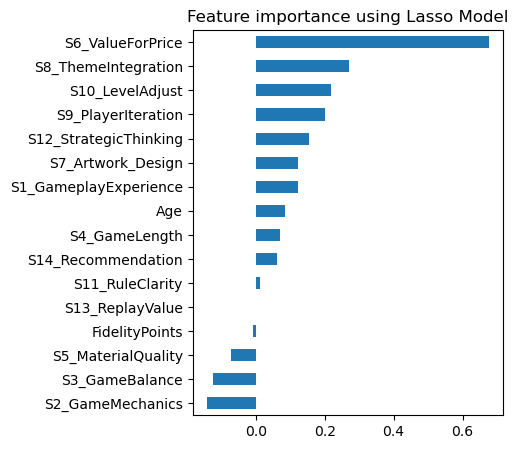


----------------- DT ----------------------


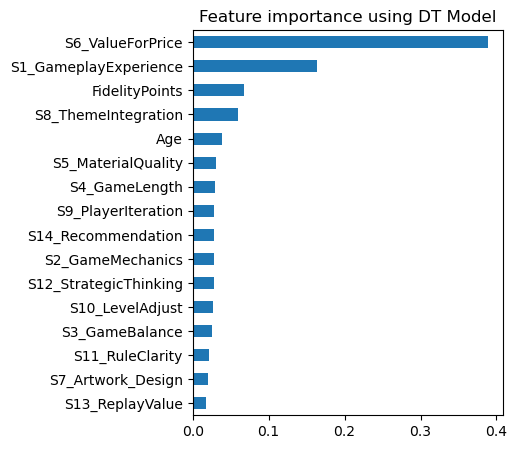

_________________________________________________________________________________________________

                                     SPLIT 2                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


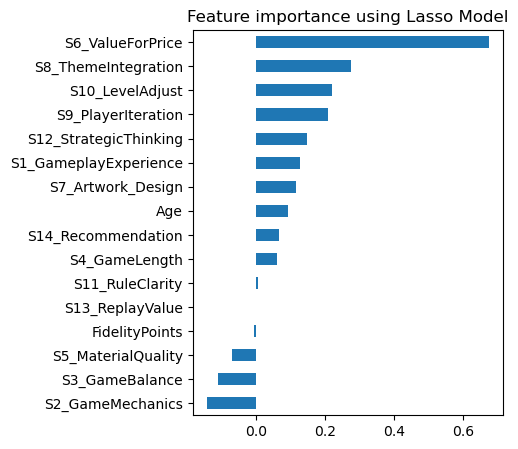


----------------- DT ----------------------


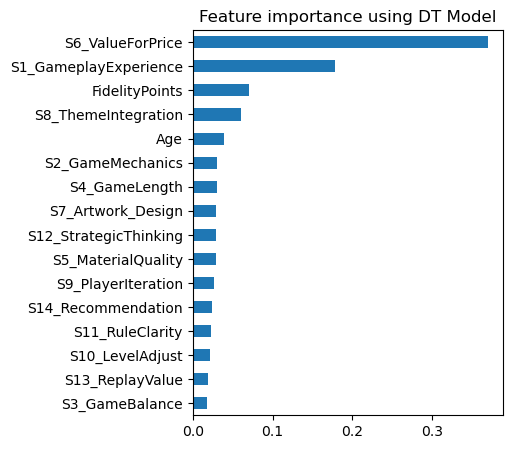

_________________________________________________________________________________________________

                                     SPLIT 3                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


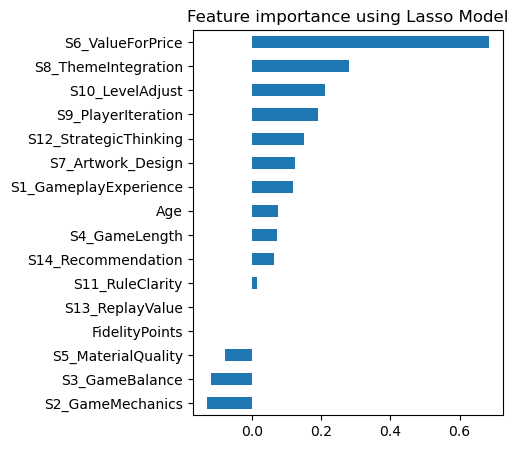


----------------- DT ----------------------


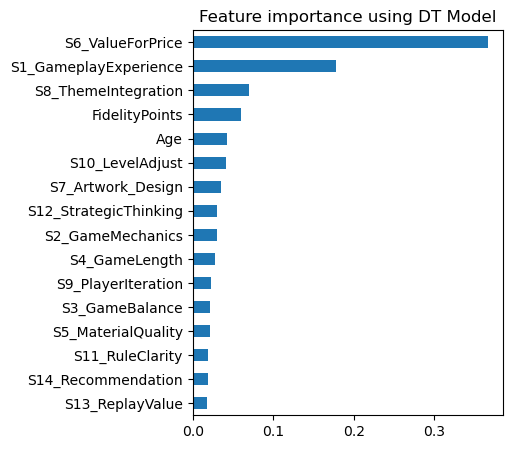

_________________________________________________________________________________________________

                                     SPLIT 4                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


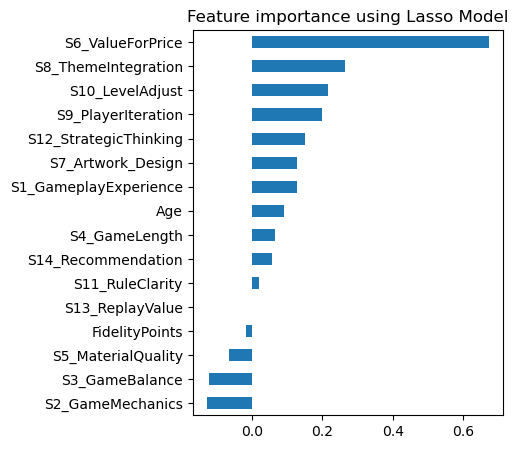


----------------- DT ----------------------


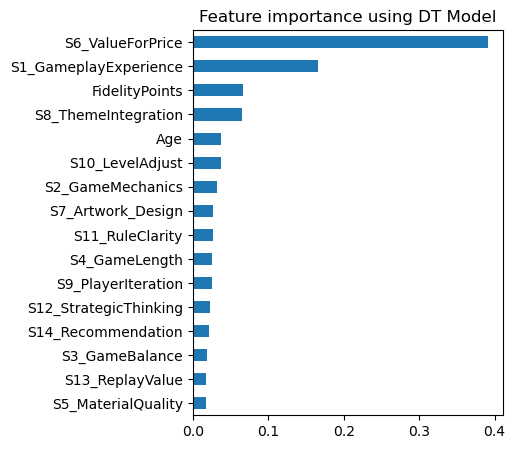

_________________________________________________________________________________________________

                                     SPLIT 5                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


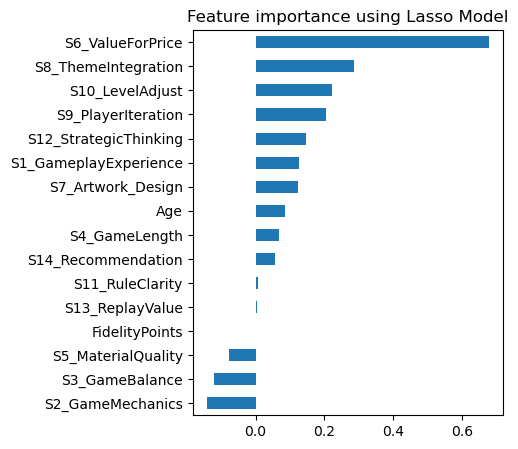


----------------- DT ----------------------


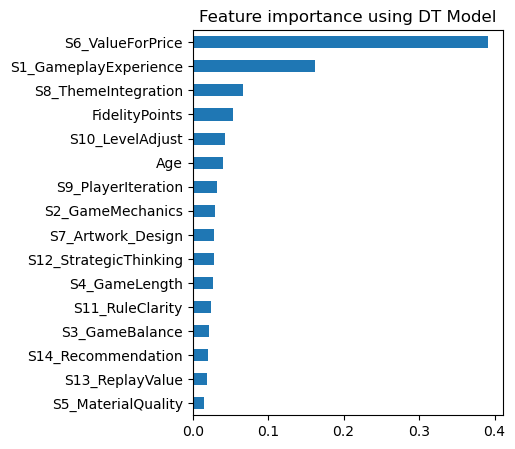

_________________________________________________________________________________________________

                                     SPLIT 6                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


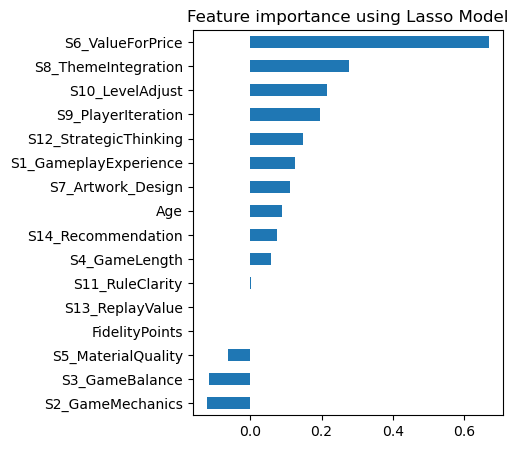


----------------- DT ----------------------


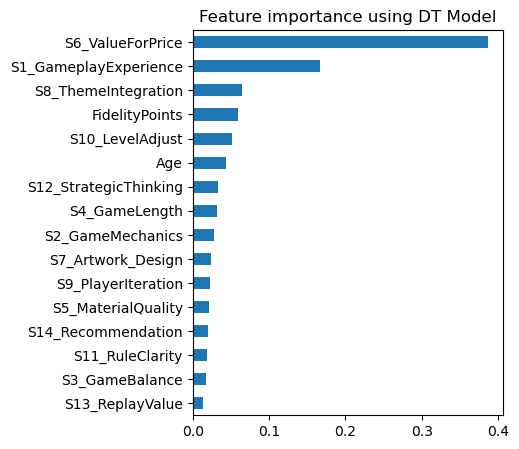

_________________________________________________________________________________________________

                                     SPLIT 7                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


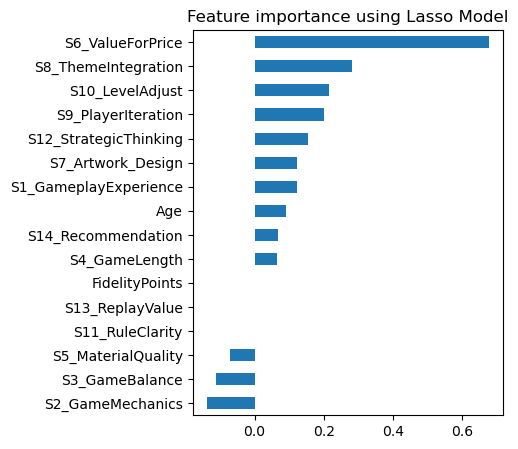


----------------- DT ----------------------


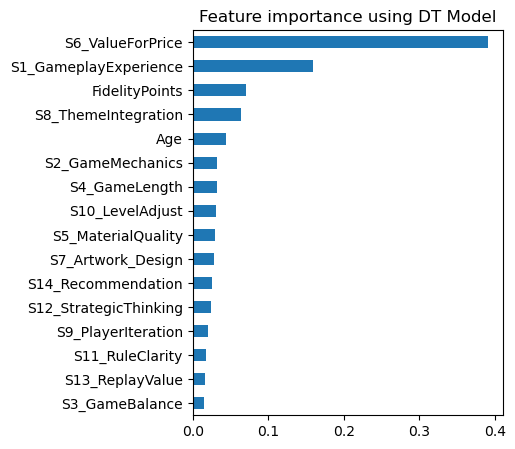

_________________________________________________________________________________________________

                                     SPLIT 8                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


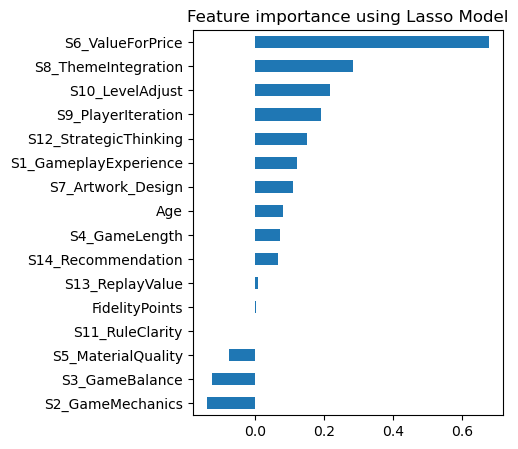


----------------- DT ----------------------


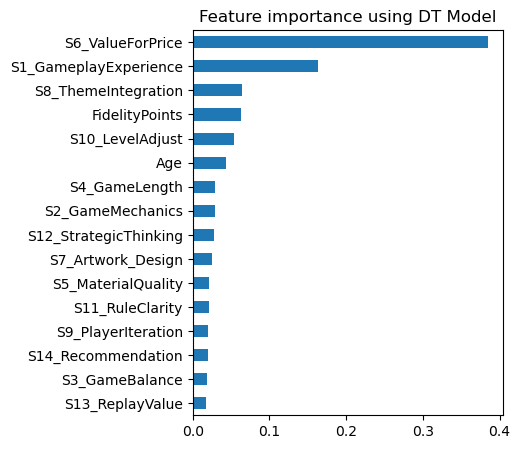

_________________________________________________________________________________________________

                                     SPLIT 9                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


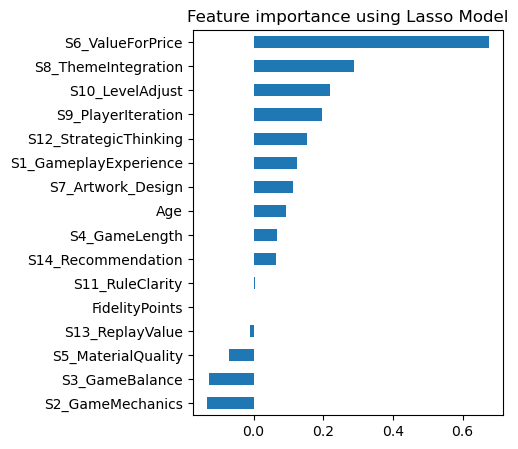


----------------- DT ----------------------


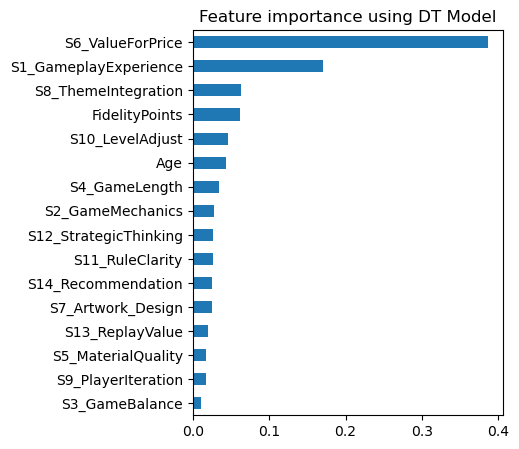

_________________________________________________________________________________________________

                                     SPLIT 10                                    
_________________________________________________________________________________________________

----------------- RFE ----------------------
FidelityPoints           False
S1_GameplayExperience    False
S2_GameMechanics         False
S3_GameBalance           False
S4_GameLength            False
S5_MaterialQuality       False
S6_ValueForPrice          True
S7_Artwork_Design        False
S8_ThemeIntegration       True
S9_PlayerIteration        True
S10_LevelAdjust           True
S11_RuleClarity          False
S12_StrategicThinking     True
S13_ReplayValue          False
S14_Recommendation       False
Age                      False
dtype: bool

----------------- LASSO ----------------------


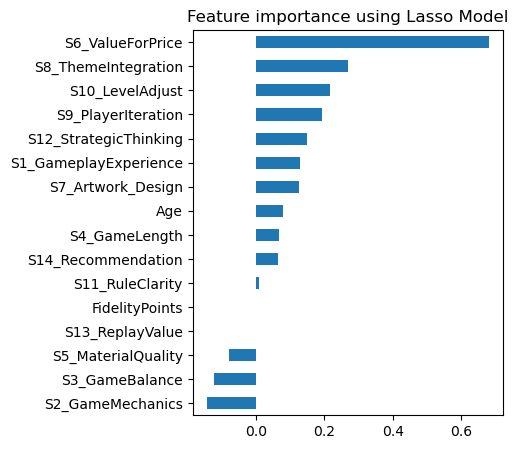


----------------- DT ----------------------


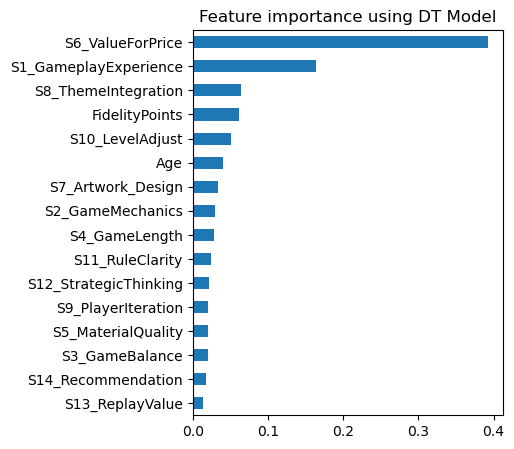

In [55]:
# Calling the function select_best_features passing as arguments your independent variables and your target
select_best_features(X, y)

<a name='MIC_feature'></a>

<font color = '#C04000'>

#### **3.6.3. MIC Feature Selection**

In [56]:
from sklearn.feature_selection import mutual_info_regression
def calculate_mic_scores(X, y):
    mic_scores = mutual_info_regression(X, y)
    return mic_scores

# Function to select top features based on MIC scores
def select_top_features(X, mic_scores, k):
    top_k_indices = np.argsort(mic_scores)[-k:]  # Get indices of top-k features
    top_k_features = X.columns[top_k_indices]
    top_k_scores = mic_scores[top_k_indices]
    return top_k_features, top_k_scores

In [57]:
def select_best_features_MIC(X, y):
    numerical_columns = X.select_dtypes(include=np.number).columns
    X_numeric = X[numerical_columns]  # Select only numerical columns

    skf = StratifiedKFold(n_splits=10)

    all_selected_features = []
    all_selected_scores = []

    for train_index, val_index in skf.split(X_numeric, y):
        X_train, X_val = X_numeric.iloc[train_index], X_numeric.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        mic_scores = calculate_mic_scores(X_train, y_train)

        # Example: Select top 30 features based on MIC scores
        k = 30

        selected_features, selected_scores = select_top_features(X_train, mic_scores, k)

        all_selected_features.append(selected_features)
        all_selected_scores.append(selected_scores)

    # Convert to numpy arrays for easier manipulation
    all_selected_scores = np.array(all_selected_scores)

    # Compute average scores across folds
    avg_scores = np.mean(all_selected_scores, axis=0)

    # Get top-k indices based on average scores
    sorted_indices = np.argsort(avg_scores)[::-1]
    selected_features = all_selected_features[0][sorted_indices]  # Use features from first split
    avg_scores = avg_scores[sorted_indices]

    print("Average top features and their MIC scores (in descending order):")
    for feature, score in zip(selected_features, avg_scores):
        print(f"{feature}: {score}")

In [58]:
select_best_features_MIC(X, y)

Average top features and their MIC scores (in descending order):
S6_ValueForPrice: 0.23016096952383389
S1_GameplayExperience: 0.14111950338225218
S8_ThemeIntegration: 0.10909146308733444
S7_Artwork_Design: 0.10143459486892521
S9_PlayerIteration: 0.0703887855484325
S14_Recommendation: 0.06458528493534335
S10_LevelAdjust: 0.05942608280570303
S13_ReplayValue: 0.050211593321697646
S11_RuleClarity: 0.04581087966035913
S5_MaterialQuality: 0.04128209041219533
S12_StrategicThinking: 0.03517656097714354
Age: 0.03172422421022647
S3_GameBalance: 0.02861699666754003
FidelityPoints: 0.021646384119522643
S4_GameLength: 0.00906087349739364
S2_GameMechanics: 0.0007771443567638591


For MIC the less important variables are: `S2_GameMechanics`, `S4_GameLength`, `Age`and `FidelityPoints`.

### RECAP

`Which variables should we remove using this techniques?`

| Predictor | Chi-Quare | RFE | Lasso | DT | MIC | What to do? |
| --- |--- | --- | --- | --- | --- | --- |
FidelityPoints | X | 10 NO | 8 NO | - | Low Score | Try with and without |
S1_GameplayExperience | - | 10 NO | - | - | - | KEEP |
S2_GameMechanics | 1 NO | 10 NO | - | - | Low Score | Try with and without |
S3_GameBalance | - | 10 NO | - | - | - | KEEP |
S4_GameLength | - | 10 NO | - | - | Low Score | Try with and without |
S5_MaterialQuality | - | 10 NO | - | 10 NO | - | Try with and without |
S6_ValueForPrice | 10 YES | 10 YES | 10 YES | 10 YES | Highest Score | Try with and without |
S7_Artwork_Design | - | 10 NO | - | - | - | KEEP |
S8_ThemeIntegration | - | - | - | - | - | KEEP |
S9_PlayerIteration | - | - | - | - | - | KEEP |
S10_LevelAdjust | - | - | - | - | - | KEEP |
S11_RuleClarity | - | 10 NO | - | 4 NO | - | Try with and without |
S12_StrategicThinking | - | - | - | - | - | KEEP |
S13_ReplayValue | - | 10 NO | 4 NO | 9 NO | - | Try with and without |
S14_Recommendation | - | 10 NO | - | 2 NO | - | KEEP |
Age | X | 10 NO | - | - | Low Score | Try with and without |
Gender | - | X | X | X | - | KEEP |
Newsletter_Subscription | - | X | X | X | - | KEEP |
Membership | - | X | X | X | - | KEEP |
Preferred_Game_Genre | - | X | X | X | - | KEEP |

<a name='model_assess'></a>

<font color = '#C04000'>
    
# **4. Model & Assess (Modelling and Assessment)** </font>

<a name='model_selection'></a>

<font color = '#C04000'>
    
## **4.1. Model Selection** </font>

Creating a function called encode_data that will receive one dataset and make the following changes in the categorical data:
* Create dummies on your data set for the categorical columns: `Newsletter_Subscription`, `Membership`, `Preferred_Game_Genre` and `Gender`.

In [59]:
def encode_data(dataset):
    # Encode categorical variables as dummy variables
    data_dummies = pd.get_dummies(dataset)
    columns_to_drop = ['Newsletter_Subscription_no', 'Membership_Non-Premium', 'Preferred_Game_Genre_Thematic','Gender_F']
    for column in columns_to_drop:
        if column in data_dummies.columns:
            data_dummies.drop(column, axis=1, inplace=True)
    return data_dummies

In [60]:
def select_best_models(data, model):
    skf = StratifiedKFold(n_splits = 10, random_state = 99, shuffle = True)
    X = data.drop('Buy_product', axis = 1)
    y = data['Buy_product'].copy()
    X = encode_data(X)
    score_train, score_val = [],[]
    # perform the cross-validation
    for train_index, val_index in skf.split(X,y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Scale the data
        scaler = MinMaxScaler().fit(X_train)
        X_train = scaler.transform(X_train)
        X_val = scaler.transform(X_val)

        # Apply model
        model.fit(X_train, y_train)
        predictions_train = model.predict(X_train)
        predictions_val = model.predict(X_val)
        score_train.append(f1_score(y_train, predictions_train))
        score_val.append(f1_score(y_val, predictions_val))

    avg_train = round(np.mean(score_train),3)
    avg_val = round(np.mean(score_val),3)
    std_train = round(np.std(score_train),2)
    std_val = round(np.std(score_val),2)

    return avg_train, std_train, avg_val, std_val

In [61]:
def show_results(df, data, *args):
    count = 0
    # for each instance of model passed as argument
    for arg in args:
        avg_train, std_train, avg_val, std_val = select_best_models(data, arg)
        # store the results in the right row
        df.iloc[count] = str(avg_train) + '+/-' + str(std_train), str(avg_val) + '+/-' + str(std_val)
        count+=1
    return df

<a name='comparing_algorithms'></a>

<font color = '#C04000'>
    
### **4.1.1. Compare different algorithms and select the most promising ones** </font>

The first thing we are going to do is to compare the performance of different algorithms with the columns combination that  we selected
- We are going to try KNN, DT, RandomFlorest, SVC, RF and GB with defaults parameters
- For NN we are going to use max_iterations = 2000

In [62]:
model_KNN = KNeighborsClassifier()
model_DT = DecisionTreeClassifier( random_state = 99)
model_NN = MLPClassifier(max_iter = 2000, random_state = 99)
model_rf = RandomForestClassifier(random_state = 99, n_jobs=-1)
model_gb = GradientBoostingClassifier(random_state=99)
model_svc = SVC(random_state = 99)
df_1 = pd.DataFrame(columns = ['Train','Validation'], index = ['KNN','DT','NN', 'RF', 'GB','SVC'])

In [63]:
df_2 = pd.DataFrame(columns = ['Train','Validation'], index = ['KNN','DT','NN', 'RF', 'GB','SVC'])

In [64]:
show_results(df_1,data_processed, model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

,Train,Validation
KNN,0.936+/-0.0,0.911+/-0.01
DT,1.0+/-0.0,0.923+/-0.01
NN,0.961+/-0.0,0.943+/-0.01
RF,1.0+/-0.0,0.943+/-0.01
GB,0.935+/-0.0,0.93+/-0.01
SVC,0.94+/-0.0,0.93+/-0.01


In [65]:
data_without_fi_columns = list(data_processed.columns.difference(['FidelityPoints']))
data_without_fi = data_processed[data_without_fi_columns].copy()
data_without_s13_columns = list(data_processed.columns.difference(['S13_ReplayValue']))
data_without_s13 = data_processed[data_without_s13_columns ].copy()
data_without_s2_columns = list(data_processed.columns.difference(['S2_GameMechanics']))
data_without_s2 = data_processed[data_without_s2_columns].copy()
data_without_s4_columns = list(data_processed.columns.difference(['S4_GameLength']))
data_without_s4 = data_processed[data_without_s4_columns].copy()
data_without_age_columns = list(data_processed.columns.difference(['Age']))
data_without_age = data_processed[data_without_age_columns].copy()
data_without_s3_columns= list(data_processed.columns.difference(['S3_GameBalance']))
data_without_s3= data_processed[data_without_s3_columns].copy()
data_without_s6_columns = list(data_processed.columns.difference(['S6_Value_Price']))
data_without_s6 = data_processed[data_without_s6_columns].copy()
data_without_s5_columns = list(data_processed.columns.difference(['S5_MateralQuality']))
data_without_s5 = data_processed[data_without_s5_columns].copy()
data_without_s11_columns = list(data_processed.columns.difference(['S11_RuleClarity']))
data_without_s11 = data_processed[data_without_s11_columns ].copy()


#### Testing removing each feature

In [66]:

show_results(df_1, data_without_fi, model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

,Train,Validation
KNN,0.937+/-0.0,0.911+/-0.01
DT,1.0+/-0.0,0.923+/-0.01
NN,0.96+/-0.0,0.941+/-0.01
RF,1.0+/-0.0,0.944+/-0.01
GB,0.934+/-0.0,0.93+/-0.01
SVC,0.94+/-0.0,0.93+/-0.01


In [67]:
show_results(df_1, data_without_s13 , model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

,Train,Validation
KNN,0.936+/-0.0,0.912+/-0.01
DT,1.0+/-0.0,0.919+/-0.01
NN,0.955+/-0.0,0.939+/-0.01
RF,1.0+/-0.0,0.944+/-0.01
GB,0.933+/-0.0,0.93+/-0.01
SVC,0.94+/-0.0,0.93+/-0.01


In [68]:
show_results(df_1, data_without_s2, model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

,Train,Validation
KNN,0.937+/-0.0,0.909+/-0.01
DT,1.0+/-0.0,0.921+/-0.01
NN,0.958+/-0.0,0.94+/-0.01
RF,1.0+/-0.0,0.942+/-0.01
GB,0.932+/-0.0,0.928+/-0.01
SVC,0.938+/-0.0,0.928+/-0.01


In [69]:
show_results(df_1, data_without_s4, model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

,Train,Validation
KNN,0.938+/-0.0,0.911+/-0.01
DT,1.0+/-0.0,0.921+/-0.01
NN,0.956+/-0.0,0.939+/-0.01
RF,1.0+/-0.0,0.944+/-0.01
GB,0.933+/-0.0,0.931+/-0.01
SVC,0.94+/-0.0,0.93+/-0.01


In [70]:
show_results(df_1, data_without_age, model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

,Train,Validation
KNN,0.936+/-0.0,0.91+/-0.01
DT,1.0+/-0.0,0.922+/-0.01
NN,0.957+/-0.0,0.942+/-0.01
RF,1.0+/-0.0,0.944+/-0.01
GB,0.933+/-0.0,0.93+/-0.01
SVC,0.94+/-0.0,0.93+/-0.01


In [ ]:
show_results(df_1, data_without_s3, model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

In [ ]:
show_results(df_1, data_without_s6, model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

In [ ]:
show_results(df_1, data_without_s5, model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

In [ ]:
show_results(df_1, data_without_s11, model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

#### Trying to find the best combinations

__`Fidelity`__ , __`YearBirth`__ , __`S13_ReplayValue`__ , __`S6_Value_Price`__, __`S5_MateralQuality`__', don't add any additional info to the model and removing them reduces overfitting in the models, which was our main concern in the begining with this dataset.


In [ ]:
data_without_s6_a_s13_fi_columns= list(data_processed.columns.difference(['S6_Value_Price', 'Age','S13_ReplayValue','FidelityPoints']))
data_without_s6_a_s13_fi = data_processed[data_without_s6_a_s13_fi_columns].copy()

data_without_s6_a_s13_fi_s5_columns= list(data_processed.columns.difference(['S6_ValueForPrice', 'Age','S13_ReplayValue','FidelityPoints','S5_MaterialQuality']))
data_without_s6_a_s13_fi_s5= data_processed[data_without_s6_a_s13_fi_s5_columns].copy()


data_without_a_s13_fi_s5_columns= list(data_processed.columns.difference(['Age','S13_ReplayValue','FidelityPoints','S5_MaterialQuality']))
data_without_a_s13_fi_s5 = data_processed[data_without_a_s13_fi_s5_columns].copy()



data_without_a_s13_fi_columns= list(data_processed.columns.difference(['Age','S13_ReplayValue','FidelityPoints']))
data_without_a_s13_fi = data_processed[data_without_a_s13_fi_columns].copy()


In [ ]:
show_results(df_1, data_without_s6_a_s13_fi , model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

In [ ]:
show_results(df_1,data_without_s6_a_s13_fi_s5 , model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

In [ ]:
show_results(df_1, data_without_a_s13_fi_s5  , model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

In [ ]:
show_results(df_1, data_without_a_s13_fi  , model_KNN, model_DT, model_NN, model_rf, model_gb, model_svc)

In [ ]:
data_best= data_without_a_s13_fi

Our combinations _`data_without_a_s13_fi_s5`_,
_`data_without_s6_a_s13_fi_s5`_ and _`data_without_s6_a_s13_fi`_ performed exatly the same. So to simplifiy our model we prefer to go on with the simplest of them all _`data_without_s6_a_s13_fi_s5`_ and call data_best.
And decided to go on the the 4 best algorithms: SVC,GB,RF and NN
__`Summary`__:<br>
- For __`SVC`__: Validation 0.93 with difference of test and val=0.9  <br>
- For __`GB`__:  Validation 0.93 with difference of test and val=0.03 <br>
- For __`NN`__:  Validation 0.94 with difference of test and val=0.13 <br>
- For __`RF`__: Validation 0.942 with difference of test and val =0.50 <br>


<a name='model_optimization'></a>

<font color = '#C04000'>
    
## **4.2. Model Optimization** </font>

Trying to optimize the performance of your models by adjusting the algorithms' hyper-parameters and select the options that result on the best overall performance. <br>

Possible ways of doing this can be through:
* Manual optimization
* GridSearch
* RandomSearch

__We are going to do a manual optimization.__

In [ ]:
def point_plot(train, validation, values_try):
    sns.pointplot(x=values_try, y=train, color = 'teal', label = 'Train')
    sns.pointplot(x=values_try, y=validation, color = 'goldenrod', label = 'Validation')
    plt.legend()

- We will be set using `bootstrap = True` because samples can help in reducing overfitting by ensuring each tree is trained on a different subset of the data.

<a name='RF'></a>

<font color = '#C04000'>
    
### **4.2.1. Random Forest (RF)** </font>

<a name='RF_max_depth'></a>

<font color = '#C04000'>
    
#### **4.2.1.1. max_depth** </font>

This parameter limits the maximum depth of each tree

In [ ]:
def get_models_rf(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = RandomForestClassifier(max_depth = value,random_state = 99)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
values_try=[ 20,25,30]
#[None, 10, 20, 30, 40]
results_train, results_val = get_models_rf(data_best, values_try)
point_plot(results_train, results_val, values_try)

__Conclusion:__
* Our best __`max_depth`__ is 20

<a name='RF_n_estimators'></a>

<font color = '#C04000'>
    
#### **4.2.1.2. n_estimators** </font>

- Number of trees.
While not directly related to pruning, the number of trees in the forest can impact overfitting. More trees usually provide better performance, but after a certain point, the benefit diminishes.

In [ ]:
def get_models_rf(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = RandomForestClassifier(n_estimators = value, max_depth=20)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
 #[100, 200, 300, 500, 1000]
values_try = [ 300, 500, 1000]
results_train, results_val = get_models_rf(data_best, values_try)
point_plot(results_train, results_val, values_try)

- Our best __`n_estimators`__ can be 100, de default was better

<a name='RF_max_features'></a>

<font color = '#C04000'>
    
#### **4.2.1.3. max_features** </font>

- This parameter controls the number of features to consider when looking for the best split. Using fewer features can reduce the models complexity and improve generalization

In [ ]:
def get_models_rf(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = RandomForestClassifier(max_features=value, n_estimators=500, max_depth=20, min_samples_split=10, random_state = 99, n_jobs=-1)
    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
#['auto', 'sqrt', 'log2']
values_try = ['auto', 'sqrt', 'log2']
values_try = [0.5,0.6,0.7, 0.8]
results_train, results_val = get_models_rf(data_best, values_try)
point_plot(results_train, results_val, values_try)

- Our best __`max_features`__ is 0.6

<a name='RF_min_samples_split'></a>

<font color = '#C04000'>
    
#### **4.2.1.4. min_samples_split** </font>

In [ ]:
def get_models_rf(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = RandomForestClassifier(  n_estimators=1000,bootstrap=True, max_depth=20, min_samples_split=value, n_jobs=-1)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
#[2, 5, 10]
values_try = [5,10,20]
results_train, results_val = get_models_rf(data_best, values_try)
point_plot(results_train, results_val, values_try)

- Our best __`min_samples_slipt`__ is 17-20

<a name='RF_min_samples_leaf'></a>

<font color = '#C04000'>
    
#### **4.2.1.5. min_samples_leaf** </font>

- This parameter determines the minimum number of samples required to be at a leaf node. Increasing this value can ensure that leaf nodes have enough data points to make reliable decisions

In [ ]:
def get_models_dt(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = RandomForestClassifier(  bootstrap=True, min_samples_split=10, max_depth=20, min_samples_leaf=value, random_state = 99, n_jobs=-1)


    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
#Typical Range: 1 to 20
values_try = [1,2, 5,10]
results_train, results_val = get_models_dt(data_best, values_try)
point_plot(results_train, results_val, values_try)

min_samples_leaf is 1, trying increasing min_splits, to reduce the overfitting

### RF optimized

In [ ]:
model_best_rf= RandomForestClassifier(max_features=0.6,
                                        n_estimators=1000,
                                        max_depth=20,
                                        min_samples_split=17,
                                         min_samples_leaf=1,
                                        random_state = 99,
                                        n_jobs=-1
                                        )

- max_depth: Limit the depth of trees to prevent overfitting.
- min_samples_split: Ensure splits occur only with a sufficient number of samples. Typical Range: 2 to 20. Higher values reduce overfitting.
- min_samples_leaf: Require a minimum number of samples in leaf nodes. Typical Range: 1 to 20. Higher values reduce overfitting
- max_features: Control the number of features considered for splits.  Lower values reduce overfitting.

- bootstrap: Use bootstrap samples for building trees.
- max_samples: Control the size of the bootstrap samples.

<a name='SVC'></a>

<font color = '#C04000'>
    
### **4.2.2. Support Vector Classification (SVC)** </font>

<a name='SVC_C'></a>

<font color = '#C04000'>
    
#### **4.2.2.1. C** </font>

In [ ]:
def get_models_dt(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = SVC(random_state=99, C=value)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
values_try = [0.1, 1, 10, 100, 1000]
results_train, results_val = get_models_dt(data_best, values_try)
point_plot(results_train, results_val, values_try)

- The best __`C`__ is 10

<a name='SVC_kernel'></a>

<font color = '#C04000'>
    
#### **4.2.2.2. kernel** </font>

In [ ]:
def get_models_dt(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = SVC(random_state=99, C=10)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
values_try = ['linear', 'poly', 'rbf', 'sigmoid']
results_train, results_val = get_models_dt(data_best, values_try)
point_plot(results_train, results_val, values_try)

- The best __`kernel`__ is poly

<a name='SVC_gamma'></a>

<font color = '#C04000'>
    
#### **4.2.2.3. gamma** </font>

In [ ]:
def get_models_dt(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = SVC(random_state=99,  gamma=value)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
values_try = ['scale', 'auto', 0.001, 0.01, 0.1, 1]
results_train, results_val = get_models_dt(data_best, values_try)
point_plot(results_train, results_val, values_try)

#### Best SVC

In [ ]:
model_best_svc=SVC(random_state=99, C=10,
                   kernel='poly',
                   gamma=0.1)


- Our best Svc hyperparameters  are
C-=10
kernel=poly
gamma=0.1

<a name='GB'></a>

<font color = '#C04000'>
    
### **4.2.3. Gradient Boosting (GB)** </font>

<a name='GB_n_estimators'></a>

<font color = '#C04000'>
    
#### **4.2.3.1. n_estimators** </font>

In [ ]:
def get_models_dt(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = GradientBoostingClassifier(random_state=99, n_estimators=value)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
values_try = [ 1000,1500, 2000]
results_train, results_val = get_models_dt(data_best, values_try)
point_plot(results_train, results_val, values_try)

The best can be up to 1000 as our model is underfitting at this point. so lets go with 2000

<a name='GB_learning_rate'></a>

<font color = '#C04000'>
    
#### **4.2.3.2. learning_rate** </font>

In [ ]:
def get_models_dt(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = GradientBoostingClassifier(random_state=99, max_depth=6,learning_rate=value,n_estimators= 2000 )

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
values_try = [0.001,0.01,0.03]
results_train, results_val = get_models_dt(data_best, values_try)
point_plot(results_train, results_val, values_try)

- The best __`learning_rate`__ is 0.01

<a name='GB_max_depth'></a>

<font color = '#C04000'>
    
#### **4.2.3.3. max_depth** </font>

In [ ]:
def get_models_gb(data, values):
    models = dict()
    results_train, results_val = [],[]

    # create the instances of each model with different values
    for value in values:
        models['depth_' + str(value)] = GradientBoostingClassifier(random_state=99,  max_depth=value )

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)

    return results_train, results_val

In [ ]:
values_try = [3,4,5]
results_train, results_val = get_models_gb(data_best, values_try)
point_plot(results_train, results_val, values_try)

- max_depth=4

In [ ]:
model_best_gb=GradientBoostingClassifier(random_state=99,
                                         n_estimators=2000,
                                         learning_rate=0.01,
                                         max_depth=4 )



- Our best GB hyperparameters  are
n_estimators----1000
learning_rate---0.02
max_depth------  4


<a name='NN'></a>

<font color = '#C04000'>
    
### **4.2.4. Neural Network (NN)** </font>

<a name='NN_hidden_layer_sizes'></a>

<font color = '#C04000'>
    
#### **4.2.4.1. hidden_layer_sizes** </font>

In [ ]:
def get_models_nn(data, values):
    models = dict()
    results_train, results_val, names = [],[],[]

    # create the instances of each model with different values
    for value in values:
        models[str(value)] = MLPClassifier(hidden_layer_sizes = value, max_iter = 2000, random_state = 99)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)
        names.append(name)

    return results_train, results_val, names

In [ ]:
values_try = [(100),(110,),(200),(300)]
results_train, results_val, names = get_models_nn(data_best, values_try)
point_plot(results_train, results_val, names)

-Best hidden_layer_sizes is 200

<a name='NN_activation'></a>

<font color = '#C04000'>
    
#### **4.2.4.2. activation** </font>

In [ ]:
# def get_models_nn(data, values):
#     models = dict()
#     results_train, results_val, names = [],[],[]

#     # create the instances of each model with different values
#     for value in values:
#         models[str(value)] = MLPClassifier( activation=value, max_iter = 2000, random_state = 99)

#     for name, model in models.items():
#         avg_train, std_train, avg_val, std_val = select_best_models(data, model)
#         results_train.append(avg_train)
#         results_val.append(avg_val)
#         names.append(name)

#     return results_train, results_val, names

In [ ]:
# values_try = [ 'logistic', 'tanh', 'relu']
# results_train, results_val, names = get_models_nn(data_best, values_try)
# point_plot(results_train, results_val, names)

<a name='NN_solver'></a>

<font color = '#C04000'>
    
#### **4.2.4.3. solver** </font>

In [ ]:
def get_models_nn(data, values):
    models = dict()
    results_train, results_val, names = [],[],[]

    # create the instances of each model with different values
    for value in values:
        models[str(value)] = MLPClassifier( max_iter = 2000, random_state = 99, solver=value)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)
        names.append(name)

    return results_train, results_val, names

In [ ]:
values_try =['adam', 'sgd']
results_train, results_val, names = get_models_nn(data_best, values_try)
point_plot(results_train, results_val, names)

<a name='NN_alpha'></a>

<font color = '#C04000'>
    
#### **4.2.4.4. alpha** </font>

In [ ]:
def get_models_nn(data, values):
    models = dict()
    results_train, results_val, names = [],[],[]

    # create the instances of each model with different values
    for value in values:
        models[str(value)] = MLPClassifier( max_iter = 2000,alpha=value,random_state = 99)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)
        names.append(name)

    return results_train, results_val, names

In [ ]:
values_try = [ 0.0001, 0.001, 0.01]
results_train, results_val, names = get_models_nn(data_best, values_try)
point_plot(results_train, results_val, names)

<a name='NN_learning_rate'></a>

<font color = '#C04000'>
    
#### **4.2.4.5. learning_rate** </font>

In [ ]:
# def get_models_nn(data, values):
#     models = dict()
#     results_train, results_val, names = [],[],[]

#     # create the instances of each model with different values
#     for value in values:
#         models[str(value)] = MLPClassifier(max_iter = 2000, learning_rate=value, random_state = 99)

#     for name, model in models.items():
#         avg_train, std_train, avg_val, std_val = select_best_models(data, model)
#         results_train.append(avg_train)
#         results_val.append(avg_val)
#         names.append(name)

#     return results_train, results_val, names

In [ ]:
# values_try = ['constant', 'adaptive']
# results_train, results_val, names = get_models_nn(data_best, values_try)
# point_plot(results_train, results_val, names)

<a name='NN_learning_rate_init'></a>

<font color = '#C04000'>
    
#### **4.2.4.6. learning_rate_init** </font>

In [ ]:
def get_models_nn(data, values):
    models = dict()
    results_train, results_val, names = [],[],[]

    # create the instances of each model with different values
    for value in values:
        models[str(value)] = MLPClassifier( max_iter = 2000, learning_rate_init=value,hidden_layer_sizes = (200),random_state = 99)

    for name, model in models.items():
        avg_train, std_train, avg_val, std_val = select_best_models(data, model)
        results_train.append(avg_train)
        results_val.append(avg_val)
        names.append(name)

    return results_train, results_val, names

In [ ]:
values_try = [0.001, 0.01, 0.1]
results_train, results_val, names = get_models_nn(data_best, values_try)
point_plot(results_train, results_val, names)

In [ ]:

model_best_nn=MLPClassifier(max_iter = 2000,
                            hidden_layer_sizes=(150,),
                            early_stopping=True,
                             random_state = 99)

<a name='winner_model'></a>

<font color = '#C04000'>
    
## **4.3. Selecting the Winner Model** </font>

In [ ]:
df_SC = pd.DataFrame(columns = ['Train','Validation'], index = ['Model'])

In [ ]:
show_results(df_SC,data_best,model_best_svc)

In [ ]:
show_results(df_SC,data_best,model_best_rf) #### dif 24 Ou 25

In [ ]:
show_results(df_SC,data_best, model_best_gb) ### dif 17

In [ ]:
show_results(df_SC,data_best, model_best_nn) ####---dif 19---NNNNNNN

- Our best one is GB so lets apply GB as our final estimator on stacking

<a name='combining_models'></a>

<font color = '#C04000'>
    
## **4.4. Combining the Best Models** </font>

In [ ]:
base_models = [
    ('gb', model_best_gb)
]


In [ ]:
stacking_gb = StackingClassifier(
    estimators=base_models,
    final_estimator= model_best_gb,
    cv=5,
    n_jobs=-1
)
show_results(df_SC, data_best, stacking_gb)

In [ ]:
stacking_gb = StackingClassifier(
    estimators=base_models,
    final_estimator= model_best_nn,
    cv=5,
    n_jobs=-1
)
show_results(df_SC, data_best, stacking_gb)

In [ ]:
final_model=model_best_gb

<a name='deploy'></a>

<font color = '#C04000'>
    
# **5. Deploy** </font>

In [ ]:
# Processing the test
train=data_processed[data_best.columns]
X_train = train.drop(['Buy_product'], axis = 1)
y_train = train['Buy_product'].copy()
train_columns=X_train.columns
test = pd.read_csv(r'test.csv')
test=test.copy()
test.set_index("Cust_ID", inplace=True)
test['Gender'] = test['Name'].apply(lambda x: 'F' if x.split(' ')[0]=='Ms.' else 'M')

In [ ]:
# Fitting
train = encode_data(X_train)
test = encode_data(test)
test=test[train.columns]
scaler = MinMaxScaler().fit(train)
train = pd.DataFrame(scaler.transform(train), columns = train.columns)
test = pd.DataFrame(scaler.transform(test), columns = test.columns, index = test.index)

In [ ]:
# Fitting
model_best_rf.fit(train, y_train)
predictions_train = final_model.predict(train)
train_f1_score = f1_score(y_train, predictions_train)
print(f"Training F1 Score: {train_f1_score}")
predictions = final_model.predict(test)

In [ ]:
answer=pd.DataFrame()
answer['Cust_ID']=test.index
answer['Buy_product']=predictions
answer.head()
answer.to_csv(f'DSML_Group18__Version15.csv', index = False)